#**AI INVENTORY OPTIMIZER**
#CLASS: ITAI 2277
#Members: Milagros Pumasupa, Ahad Maredia, Larry Towett, Yasmin Bello

#**Model Optimization and Evaluation**
-------------------------------------------
This phase focuses on selecting, evaluating, and comparing machine learning models
for the AI Inventory Optimizer. The goal is to accurately forecast weekly product
demand to support smarter inventory management and improve operational efficiency.

A baseline Linear Regression model was compared against ensemble methods
(Random Forest and Gradient Boosting), and finally, an optimized XGBoost model
was implemented to enhance predictive performance.

The dataset (walmart_preprocessed.csv) contains engineered features such as
store size, type, markdowns, economic indicators (CPI, unemployment), and
time-based attributes. Data was split into 80% training and 20% testing sets,
preserving temporal order to maintain time-series consistency.



AI system for inventory optimization in convenience stores.
Predicts weekly product demand, recommends trending items, and generates actionable insights via a dashboard.
Aims to reduce overstock/understock, minimize waste, and improve profitability through data-driven decisions.


#**1. Data Loading and Time Series preparation**
This section loads the preprocessed dataset, removes unnecessary columns,
separates features (X) and target (y), and splits the data into training
and testing sets while maintaining chronological order if required.
The resulting variables (X_train, X_test, y_train, y_test) will be used
for model training, optimization, and evaluation.

In [ ]:
# ============================================================
# DATA LOADING AND TIME-SERIES PREPARATION
# ============================================================

from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Load preprocessed dataset
file_path = "walmart_preprocessed.csv" #Variable will be updated according to the location.

if os.path.exists(file_path):
    df = pd.read_csv(file_path)

    # Drop the 'Date' column if it exists (not used for model training)
    if "Date" in df.columns:
        df = df.drop(columns=["Date"])

    # Separate features (X) and target (y)
    X = df.drop(columns=["Weekly_Sales"])
    y = df["Weekly_Sales"]  # y is already a pandas Series

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print("✅ Data loaded and split successfully!")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape:  {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape:  {y_test.shape}")

else:
    print(f"❌ Error: File not found at '{file_path}'. Please check the path or upload the file.")


Saving walmart_preprocessed.csv to walmart_preprocessed (1).csv
User uploaded file "walmart_preprocessed (1).csv" with length 73567215 bytes
✅ Data loaded and split successfully!
X_train shape: (337256, 22)
X_test shape:  (84314, 22)
y_train shape: (337256,)
y_test shape:  (84314,)


#**2. Baseline model training and evaluation**
- Baseline models include Linear Regression, Random Forest, and Gradient Boosting.
- These models are trained on the processed training set and evaluated on the test set.
- R² and RMSE metrics provide reference performance for weekly sales forecasting.
- Baseline results serve as a foundation for comparison with advanced models like XGBoost.


In [ ]:
# ============================================================
# BASELINE MODEL TRAINING AND EVALUATION
# ============================================================
# Train and evaluate baseline regression models for reference performance:
# - Linear Regression
# - Random Forest Regressor
# - Gradient Boosting Regressor
# Metrics: RMSE and R²
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Baseline models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)


baseline_models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

# List to store results
baseline_results_list = []

# Train and evaluate baseline models
for name, model in baseline_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)


    print(f"{name} performance:")
    print(f" - MAE: {mae:.2f}")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - R²: {r2:.4f}")


    # Append results to the list
    baseline_results_list.append({"Model": name, "RMSE": rmse, "R2": r2})

# Convert the list of results to a DataFrame
baseline_results = pd.DataFrame(baseline_results_list)

# Sort by RMSE
baseline_results = baseline_results.sort_values(by="RMSE").reset_index(drop=True)

print("\n✅ Baseline model performance summary:")
display(baseline_results)


Training Linear Regression...
Linear Regression performance:
 - MAE: 14561.99
 - RMSE: 21752.26
 - R²: 0.0926

Training Random Forest...
Random Forest performance:
 - MAE: 1334.07
 - RMSE: 3421.05
 - R²: 0.9776

Training Gradient Boosting...
Gradient Boosting performance:
 - MAE: 6905.17
 - RMSE: 11524.45
 - R²: 0.7453

✅ Baseline model performance summary:


,Model,RMSE,R2
0,Random Forest,3421.054882,0.977557
1,Gradient Boosting,11524.454001,0.745311
2,Linear Regression,21752.255503,0.092642


#**3. Advance model training and evaluation**
- This section focuses on training advanced regression models to improve predictive accuracy.
- The primary model is XGBoost, which captures non-linear relationships and complex interactions.
- Performance metrics (R² and RMSE) demonstrate the model's ability to accurately forecast weekly sales
  and support data-driven inventory management decisions.


In [ ]:
# ============================================================
# ADVANCED MODEL TRAINING AND EVALUATION
# ============================================================
# Train and evaluate advanced regression model:
# - XGBoost Regressor
# ============================================================

import xgboost as xgb

# Advanced model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1,
                             random_state=42, objective='reg:squarederror')

print("\nTraining XGBoost...")
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
mae_gb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost performance:")
print(f" - MAE: {mae_gb:.2f}")
print(f" - RMSE: {rmse_xgb:.2f}")
print(f" - R²: {r2_xgb:.4f}")

# Store advanced model result
advanced_results = pd.DataFrame([{"Model": "XGBoost", "RMSE": rmse_xgb, "R2": r2_xgb}])



Training XGBoost...
XGBoost performance:
 - MAE: 3905.45
 - RMSE: 6871.14
 - R²: 0.9095


#**4. XGBoost hyperparameter tunning and final evaluation**
- Hyperparameters (n_estimators, max_depth, learning_rate, subsample, colsample_bytree)
  were optimized using Grid Search and Randomized Search on a sample of the training data.
- The final model was trained on the full training set with the best parameters.
- Evaluation on the test set shows high R² and low RMSE, confirming strong predictive performance.
- This model captures non-linear relationships and complex interactions, supporting accurate weekly sales forecasting.



In [ ]:
# ============================================================
# XGBOOST HYPERPARAMETER TUNING AND FINAL EVALUATION
# ============================================================

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import uniform, randint
import xgboost as xgb
import numpy as np

# --- Step 1: Take a smaller sample for fast hyperparameter search ---
sample_frac = 0.2  # 20% of training data
X_train_sample = X_train.sample(frac=sample_frac, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# --- Step 2: Define base XGBoost model ---
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)

# --- Step 3: Grid Search CV on sample ---
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1],
    "colsample_bytree": [0.7, 0.8, 1]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("Running Grid Search on sample data...")
grid_search.fit(X_train_sample, y_train_sample)

print("\nBest Grid Search parameters:")
print(grid_search.best_params_)
print("Best R² score (CV on sample):", grid_search.best_score_)

# --- Step 4: Randomized Search CV on sample ---
param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("\nRunning Randomized Search on sample data...")
random_search.fit(X_train_sample, y_train_sample)

print("\nBest Randomized Search parameters:")
print(random_search.best_params_)
print("Best R² score (CV on sample):", random_search.best_score_)

# --- Step 5: Train final XGBoost model on full training set ---
# Choose either Grid or Randomized search best params
best_params = grid_search.best_params_  # o random_search.best_params_

final_xgb = xgb.XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

print("\nTraining final XGBoost on full training data...")
final_xgb.fit(X_train, y_train)

# --- Step 6: Evaluate on test set ---
y_pred_final = final_xgb.predict(X_test)
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("\nFinal XGBoost Evaluation on Test Set:")
print(f"MAE: {mae_final:.2f}")
print(f"RMSE: {rmse_final:.2f}")
print(f"R²: {r2_final:.4f}")


Running Grid Search on sample data...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Best Grid Search parameters:
{'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1}
Best R² score (CV on sample): 0.9281072638003495

Running Randomized Search on sample data...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Randomized Search parameters:
{'colsample_bytree': np.float64(0.9818496824692566), 'learning_rate': np.float64(0.18896547008552977), 'max_depth': 8, 'n_estimators': 144, 'subsample': np.float64(0.976562270506935)}
Best R² score (CV on sample): 0.9376578709164706

Training final XGBoost on full training data...

Final XGBoost Evaluation on Test Set:
MAE: 2729.85
RMSE: 4858.70
R²: 0.9547


#**5. XGBoost Feature Engineering**

In [ ]:
# ============================================================
# FEATURE ENGINEERING: Lag, Rolling, Differenced, Store×Dept
# ============================================================

import pandas as pd

# Assumes df is already loaded with columns:
# 'Store', 'Dept', 'Weekly_Sales', 'day', 'week'

# --- Sort by Store, Dept, and week/day ---
df = df.sort_values(['Store', 'Dept']).reset_index(drop=True)

# --- 1. Lag features ---
lag_weeks = [1, 2, 4]  # lag of previous weeks
for lag in lag_weeks:
    df[f'sales_lag_{lag}'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(lag)

# --- 2. Rolling averages ---
rolling_windows = [2, 4]  # rolling mean over 2 and 4 weeks
for window in rolling_windows:
    df[f'sales_roll_mean_{window}'] = (
        df.groupby(['Store','Dept'])['Weekly_Sales']
          .shift(1)
          .rolling(window)
          .mean()
    )

# --- 3. Differenced values ---
df['sales_diff_1'] = df['Weekly_Sales'] - df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['sales_diff_2'] = df['Weekly_Sales'] - df.groupby(['Store','Dept'])['Weekly_Sales'].shift(2)

# --- 4. Store × Department interaction ---
df['store_dept'] = df['Store'].astype(str) + '_' + df['Dept'].astype(str)
# Optional: use target encoding or one-hot encoding later

# --- Drop rows with NaN created by lag/rolling ---
df = df.dropna().reset_index(drop=True)

# --- Separate features and target ---
X = df.drop(columns=['Weekly_Sales'])
y = df['Weekly_Sales']

print("Feature engineering completed. Shape:", X.shape)

# ============================================================
# SHOW FEATURES AND FIRST 10 ROWS
# ============================================================

# Show all feature column names
print("Feature columns:")
print(X.columns.tolist())

# Show first 10 rows of X
print("\nFirst 10 rows of feature set:")
print(X.head(10))

# Optionally, show corresponding target values
print("\nFirst 10 target values (Weekly_Sales):")
print(y.head(10))


#**6. XGBoost with Engineered Features: Evaluation**

In [ ]:
# ============================================================
# ADVANCED XGBOOST TRAINING AND EVALUATION
# ============================================================

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Step 1: Initialize XGBoost model ---
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# --- Step 2: Train on full training set ---
print("Training XGBoost with engineered features...")
xgb_model.fit(X_train, y_train)

# --- Step 3: Make predictions on test set ---
y_pred = xgb_model.predict(X_test)

# --- Step 4: Evaluate performance ---
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nXGBoost Evaluation with Engineered Features:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


Training XGBoost with engineered features...

XGBoost Evaluation with Engineered Features:
MAE : 3433.97
RMSE: 6054.22
R²  : 0.9297


In [ ]:
# OJO REVISAR SI ES NECESARIO COLOCAR ESTO Y AGREGAR PARRAFOS A CADA SECCION

# AUTOMATIC EVALUATION REPORT GENERATOR
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

# --- Assume final_xgb is your trained XGBoost model ---
# --- X_test and y_test are your test features and target ---

# --- Step 1: Evaluate model on test set ---
y_pred = final_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# --- Step 2: Prepare evaluation report ---
report_dict = {
    "Model": ["XGBoost"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
}

report_df = pd.DataFrame(report_dict)

# --- Step 3: Save report to CSV ---
csv_path = "evaluation_report.csv"
report_df.to_csv(csv_path, index=False)
print(f"Evaluation report saved to {csv_path}")

# --- Step 4: Save report to TXT ---
txt_path = "evaluation_report.txt"
with open(txt_path, "w") as f:
    f.write("=== Evaluation Report ===\n")
    f.write(f"Model: XGBoost\n")
    f.write(f"MAE  : {mae:.2f}\n")
    f.write(f"RMSE : {rmse:.2f}\n")
    f.write(f"R²   : {r2:.4f}\n")

print(f"Evaluation report saved to {txt_path}")

# --- Step 5 (optional): Save trained model for delivery ---
model_path = "final_xgboost_model.pkl"
joblib.dump(final_xgb, model_path)
print(f"Trained model saved to {model_path}")

# --- Now you have:
# 1. evaluation_report.csv (tabular, easy to analyze)
# 2. evaluation_report.txt (human-readable)
# 3. final_xgboost_model.pkl (ready to deploy or deliver)


Evaluation report saved to evaluation_report.csv
Evaluation report saved to evaluation_report.txt
Trained model saved to final_xgboost_model.pkl


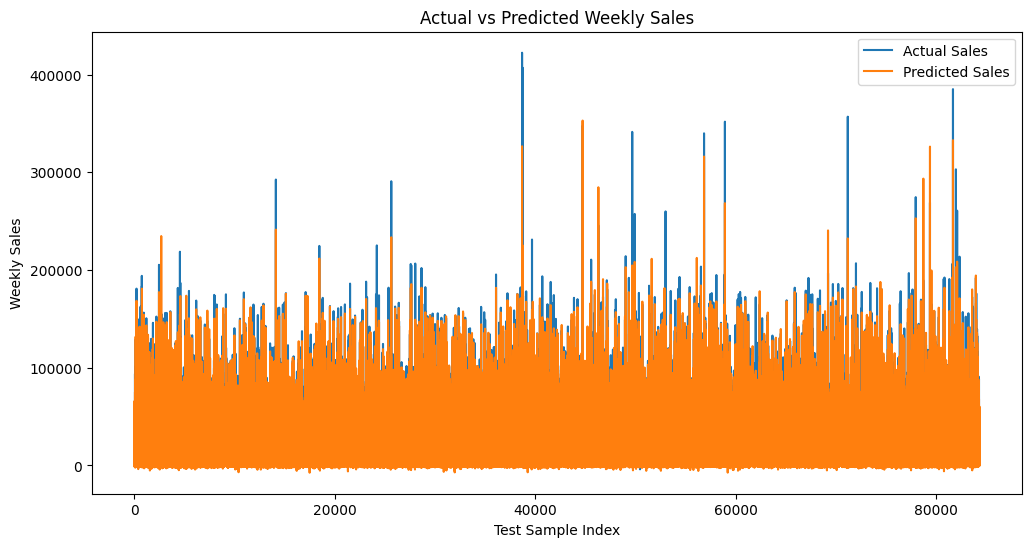

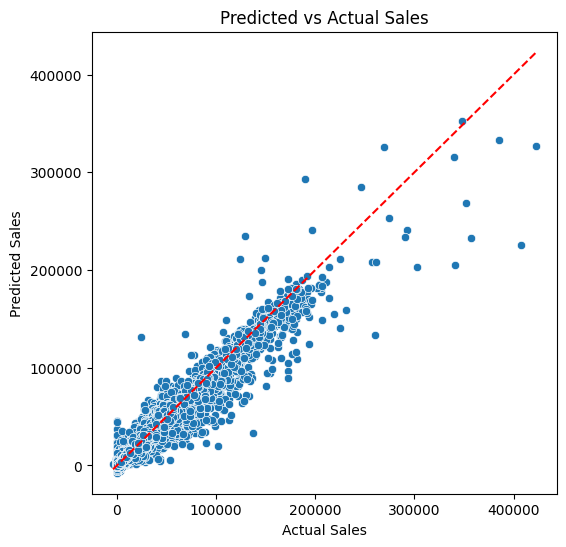

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Make predictions on test set ---
y_pred = final_xgb.predict(X_test)

# --- Plot real vs predicted sales ---
plt.figure(figsize=(12,6))
sns.lineplot(x=range(len(y_test)), y=y_test, label='Actual Sales')
sns.lineplot(x=range(len(y_test)), y=y_pred, label='Predicted Sales')
plt.title('Actual vs Predicted Weekly Sales')
plt.xlabel('Test Sample Index')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

# --- Optional: Scatter plot to see fit ---
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.title('Predicted vs Actual Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()
